# Scalable PPRL Pipeline

## Objective
Optimize linkage for large-scale EHR datasets.

In [2]:
# =================== BOOTSTRAP CELL ===================
# Standard setup for all notebooks
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[0]  # assumes notebooks are in a subfolder
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ========================================================
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# from src.config.variables import COVARIATES

# ========================================================
# Optional for warnings and nicer plots
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

import sys
from pathlib import Path

# ========================================================
# 1️⃣ Ensure project root is in Python path
# Adjust this if your notebooks are nested deeper
PROJECT_ROOT = Path.cwd().parents[0]  # assumes notebooks are in a subfolder
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ========================================================
# 2️⃣ Import helper to load paths
from src.utils.helpers import load_paths

# ========================================================
# 3️⃣ Load paths from config.yaml (works regardless of notebook location)
paths = load_paths()

# ========================================================
# 4️⃣ Optionally, print paths to confirm
for key, value in paths.items():
    print(f"{key}: {value}")

# ========================================================
# 5️⃣ Now you can use these paths in your notebook:
# Example:
SYNTHETIC_DATA_DIR = paths['SYNTHETIC_DATA_DIR']
PROCESSED_DATA_DIR = paths['PROCESSED_DATA_DIR']
FIG_DIR = paths['FIG_DIR']

# ========================================================

BASE_DIR: D:\GoogleDrive\exercises\PPRL_applications_for_evaluation\personal_pprl_bloom_filters
DATA_DIR: D:\GoogleDrive\exercises\PPRL_applications_for_evaluation\personal_pprl_bloom_filters\data
OUT_DIR: D:\GoogleDrive\exercises\PPRL_applications_for_evaluation\personal_pprl_bloom_filters\model_output
FIG_DIR: D:\GoogleDrive\exercises\PPRL_applications_for_evaluation\personal_pprl_bloom_filters\visualization
MODEL_DIR: D:\GoogleDrive\exercises\PPRL_applications_for_evaluation\personal_pprl_bloom_filters\model_output\statsmodels
NOTEBOOKS_DIR: D:\GoogleDrive\exercises\PPRL_applications_for_evaluation\personal_pprl_bloom_filters\pprl_notebooks
NOTEBOOKS_EXECUTED_DIR: D:\GoogleDrive\exercises\PPRL_applications_for_evaluation\personal_pprl_bloom_filters\notebooks_executed
RAW_DATA_DIR: D:\GoogleDrive\exercises\PPRL_applications_for_evaluation\personal_pprl_bloom_filters\data\raw
PROCESSED_DATA_DIR: D:\GoogleDrive\exercises\PPRL_applications_for_evaluation\personal_pprl_bloom_filters\data

In [3]:
import pandas as pd

matches = pd.read_csv(PROCESSED_DATA_DIR / "matches_optimized.csv")
true_matches = pd.read_csv(SYNTHETIC_DATA_DIR / "true_matches.csv")
pairs_df = pd.read_csv(PROCESSED_DATA_DIR / "all_pairs_scores.csv")

In [4]:
matches["pair"] = matches["id_A"].astype(str) + "_" + matches["id_B"].astype(str)
true_matches["pair"] = true_matches["id_A"].astype(str) + "_" + true_matches["id_B"].astype(str)
pairs_df["pair"] = pairs_df["id_A"].astype(str) + "_" + pairs_df["id_B"].astype(str)

pred = set(matches["pair"])
true = set(true_matches["pair"])

tp = len(pred & true)
fp = len(pred - true)
fn = len(true - pred)

precision = tp / (tp + fp + 1e-10)
recall = tp / (tp + fn + 1e-10)
f1 = 2 * precision * recall / (precision + recall + 1e-10)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Precision: 0.7869507323567527
Recall: 0.5909999999999409
F1: 0.6750428326179814


In [5]:
metrics = pd.DataFrame([{
    "precision": precision,
    "recall": recall,
    "f1": f1
}])

metrics.to_csv(PROCESSED_DATA_DIR / "metrics.csv", index=False)

print(f"\nMetrics DF saved: {len(metrics)}")


Metrics DF saved: 1


### Ground truth (creating labels)

In [6]:
true_set = set(true_matches["pair"])

pairs_df["label"] = pairs_df["pair"].apply(lambda x: 1 if x in true_set else 0)

### ROC + PR Curves

In [7]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_true = pairs_df["label"]
y_scores = pairs_df["similarity"]

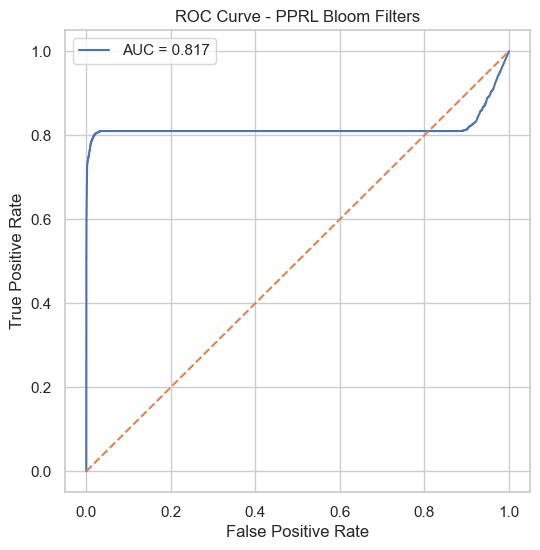

In [8]:
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - PPRL Bloom Filters")
plt.legend()

plt.savefig(FIG_DIR / "roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

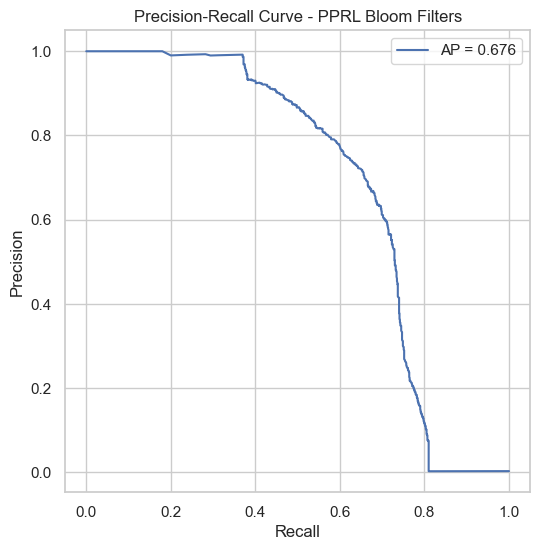

In [9]:
precision, recall, _ = precision_recall_curve(y_true, y_scores)
pr_auc = average_precision_score(y_true, y_scores)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, label=f"AP = {pr_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - PPRL Bloom Filters")
plt.legend()

plt.savefig(FIG_DIR / "pr_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
import numpy as np

thresholds = np.linspace(0, 1, 50)

metrics = []

for t in thresholds:
    preds = (y_scores >= t).astype(int)

    tp = ((preds == 1) & (y_true == 1)).sum()
    fp = ((preds == 1) & (y_true == 0)).sum()
    fn = ((preds == 0) & (y_true == 1)).sum()

    precision_val = tp / (tp + fp + 1e-10)
    recall_val = tp / (tp + fn + 1e-10)
    f1_val = 2 * precision_val * recall_val / (precision_val + recall_val + 1e-10)

    metrics.append((t, precision_val, recall_val, f1_val))

metrics_df = pd.DataFrame(metrics, columns=["threshold", "precision", "recall", "f1"])

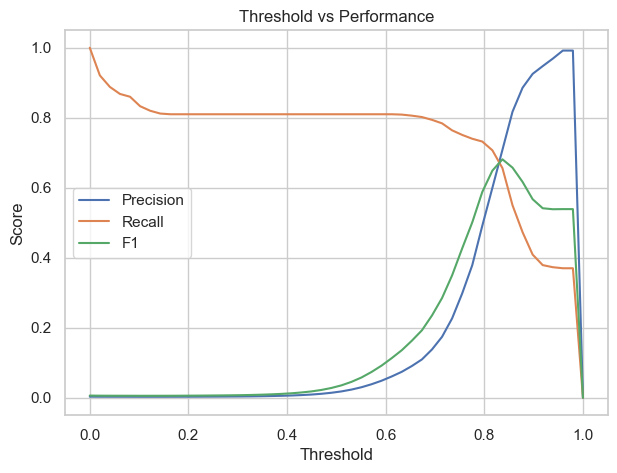

In [11]:
plt.figure(figsize=(7,5))

plt.plot(metrics_df["threshold"], metrics_df["precision"], label="Precision")
plt.plot(metrics_df["threshold"], metrics_df["recall"], label="Recall")
plt.plot(metrics_df["threshold"], metrics_df["f1"], label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Performance")
plt.legend()

plt.savefig(FIG_DIR / "threshold_analysis.png", dpi=300, bbox_inches="tight")
plt.show()